# Phase III — Kernel Methods (Support Vector Machines)
## Bank Marketing Dataset — ML Lab Project (UPC-FIB, MDS 2026)

**Authors:** Arman Bazarchi, Ines Maria Madeira Prates

---

**Prerequisites:** Run `preprocessing.ipynb` first to generate the processed data in `data/`.

This notebook trains Support Vector Machines with three kernels (linear, polynomial, RBF) and
tunes them with grid search. The central practical challenge is **scalability**: kernel SVMs cost
roughly O(n^2)-O(n^3), so a full grid search on all ~33k training rows is infeasible. We therefore
tune on a stratified subsample but evaluate every final model on the FULL test set, for a fair
comparison with the Phase II linear models.

### Outline
1. Load Processed Data & Prepare Features
2. Baseline & Subsampling Strategy
3. SVM Kernels — Default Comparison (linear / polynomial / RBF)
4. Hyperparameter Tuning — Grid Search per Kernel
5. Final Evaluation on the Test Set & Model Comparison
6. Linear-SVM Coefficients — Feature View
7. Summary & Discussion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Load Processed Data & Prepare Features

We reuse the exact feature pipeline from Phase II so results are directly comparable: drop the leaky
`duration`, one-hot encode the categorical strings, and take the same 80/20 stratified split.

In [2]:
X_scaled_df = pd.read_csv('data/X_scaled.csv')       # 15 standardized numeric features
cat_features = pd.read_csv('data/cat_features.csv')   # job, marital, month, day_of_week
y = pd.read_csv('data/y.csv')['y']

# Drop leaky 'duration' (known only after the call), one-hot the categoricals (drop_first avoids
# the dummy trap). SVMs -- especially the RBF kernel -- are distance-based, so the standardized
# numeric features + 0/1 dummies are exactly the right input scale.
X_num = X_scaled_df.drop(columns=['duration'])
X_cat = pd.get_dummies(cat_features, drop_first=True).astype(int)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Full design matrix: {X.shape}")
print(f"Train: {X_train.shape[0]} samples ({y_train.mean()*100:.2f}% positive)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean()*100:.2f}% positive)")

Full design matrix: (41188, 41)
Train: 32950 samples (11.27% positive)
Test:  8238 samples (11.26% positive)


---
## 2. Baseline & Subsampling Strategy

In [ ]:
# Mandatory baseline: a stratified dummy classifier that ignores the features entirely.
# Any real model must clearly beat this to be worth anything.
dummy = DummyClassifier(strategy='stratified', random_state=42).fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_scores = dummy.predict_proba(X_test)[:, 1]

print("Baseline (stratified dummy):")
print(f"  Accuracy: {accuracy_score(y_test, dummy_pred):.4f}")
print(f"  F1 (Yes): {f1_score(y_test, dummy_pred):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, dummy_scores):.4f}")
print(f"  AUPR:     {average_precision_score(y_test, dummy_scores):.4f}")

# The dummy scores ROC-AUC = 0.505 (= chance) and AUPR = 0.114 (= the positive rate), confirming
# it has no predictive power. Its 80% accuracy is purely an imbalance artifact -- exactly why
# accuracy is the wrong yardstick here. Every real model below must clear ROC-AUC 0.5 / AUPR 0.11.

In [4]:
# Scalability: kernel SVM training is ~O(n^2)-O(n^3) in the number of samples, so fitting (and
# especially grid-searching) on all 32,950 training rows is impractical. We tune on a stratified
# subsample, then evaluate the chosen models on the FULL test set (8,238 rows) so the reported
# numbers stay comparable with Phase II.
N_SUB = 8000
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=N_SUB, stratify=y_train, random_state=42
)
print(f"SVM tuning subsample: {X_sub.shape[0]} samples ({y_sub.mean()*100:.2f}% positive)")
print(f"Final evaluation still uses the full test set: {X_test.shape[0]} samples")

SVM tuning subsample: 8000 samples (11.26% positive)
Final evaluation still uses the full test set: 8238 samples


---
## 3. SVM Kernels — Default Comparison

Before tuning, we fit each kernel once with sensible defaults (`class_weight='balanced'`,
`gamma='scale'`) on the subsample, to see which kernels look promising and how training cost differs.
We score with `decision_function` (rank-based), so ROC-AUC / AUPR need no probability calibration.

In [ ]:
def eval_svm(name, model, Xte, yte, fit_time=None):
    scores = model.decision_function(Xte)
    pred = model.predict(Xte)
    return {
        'model': name,
        'accuracy': accuracy_score(yte, pred),
        'f1': f1_score(yte, pred),
        'roc_auc': roc_auc_score(yte, scores),
        'aupr': average_precision_score(yte, scores),
        'fit_time_s': fit_time,
    }

default_rows = []
for name, kernel in [('Linear', 'linear'), ('Polynomial', 'poly'), ('RBF', 'rbf')]:
    clf = SVC(kernel=kernel, class_weight='balanced', gamma='scale', random_state=42)
    t0 = time.perf_counter()
    clf.fit(X_sub, y_sub)
    ft = time.perf_counter() - t0
    default_rows.append(eval_svm(name, clf, X_test, y_test, ft))

default_df = pd.DataFrame(default_rows).set_index('model')
print("Default SVM kernels (trained on subsample, evaluated on full test set):")
print(default_df.round(4).to_string())

# With defaults, all three kernels land in a tight band (ROC-AUC 0.77-0.78, AUPR 0.38-0.40) and
# all crush the baseline. RBF and Linear edge out on ROC-AUC; Polynomial has the best AUPR (0.40).
# This narrow spread is the first hint that the decision boundary is close to linear -- the
# non-linear kernels do not pull ahead.
#
# Training cost: on 8,000 rows poly/RBF fit in <1s, but SVC(kernel='linear') via libsvm is
# noticeably slower (~5s) -- a known libsvm quirk (LinearSVC would be much faster). It previews
# why running any of these on all ~33k rows is impractical, motivating the subsample.

---
## 4. Hyperparameter Tuning — Grid Search per Kernel

We grid-search each kernel with 3-fold stratified CV on the subsample, optimizing **ROC-AUC**
(threshold-independent and robust to the 11% imbalance). Key hyperparameters:
- **Linear:** `C` (margin softness).
- **Polynomial:** `C`, `degree`, `gamma`.
- **RBF:** `C`, `gamma` (kernel width).

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grids = {
    'Linear': (SVC(kernel='linear', class_weight='balanced', random_state=42),
               {'C': [0.01, 0.1, 1, 10]}),
    'Polynomial': (SVC(kernel='poly', class_weight='balanced', gamma='scale', random_state=42),
                   {'C': [0.1, 1, 10], 'degree': [2, 3]}),
    'RBF': (SVC(kernel='rbf', class_weight='balanced', random_state=42),
            {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}),
}

tuned = {}
tuned_rows = []
for name, (estimator, param_grid) in grids.items():
    gs = GridSearchCV(estimator, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
    t0 = time.perf_counter()
    gs.fit(X_sub, y_sub)
    ft = time.perf_counter() - t0
    tuned[name] = gs.best_estimator_
    row = eval_svm(name, gs.best_estimator_, X_test, y_test, ft)
    row['best_params'] = gs.best_params_
    row['cv_roc_auc'] = gs.best_score_
    tuned_rows.append(row)
    print(f"{name:>11s}: best params {gs.best_params_}, CV ROC-AUC={gs.best_score_:.4f}, fit={ft:.1f}s")

tuned_df = pd.DataFrame(tuned_rows).set_index('model')

# All three kernels tune to nearly identical CV ROC-AUC (~0.767), and every winner sits on the
# SMOOTH / strongly-regularized side of its grid:
#   - Linear     -> C=0.01  (heavy regularization, small margins penalized lightly)
#   - Polynomial -> degree=2 (not 3) with C=0.1  (a mild, low-order curve)
#   - RBF        -> C=1 with gamma=0.01  (a WIDE kernel; small gamma => smooth, near-linear boundary)
# The fact that the best RBF is a wide, smooth one and the best poly is only degree 2 tells us the
# data does not reward sharp non-linear boundaries -- the structure is close to linearly separable
# in this feature space.
#
# Note the linear grid is the slowest (~22s) despite the simplest kernel -- the libsvm linear
# solver scales poorly; LinearSVC would be the scalable alternative.

---
## 5. Final Evaluation on the Test Set & Model Comparison

In [ ]:
compare = tuned_df[['accuracy', 'f1', 'roc_auc', 'aupr', 'fit_time_s']].copy()
compare.loc['Baseline (dummy)'] = [accuracy_score(y_test, dummy_pred), f1_score(y_test, dummy_pred),
                                   roc_auc_score(y_test, dummy_scores),
                                   average_precision_score(y_test, dummy_scores), np.nan]
compare = compare.sort_values('roc_auc', ascending=False)
print("Tuned SVMs vs baseline (full test set):")
print(compare.round(4).to_string())
print("\nBest tuned hyperparameters:")
for r in tuned_rows:
    print(f"  {r['model']:>11s}: {r['best_params']}")

# On the full test set the tuned kernels are nearly tied (ROC-AUC 0.784-0.793, AUPR 0.38-0.45) and
# all massively beat the baseline (ROC-AUC 0.505). Polynomial (degree 2) is best on BOTH ROC-AUC
# (0.793) and AUPR (0.451); RBF is essentially tied (0.792 / 0.424); Linear trails slightly.
#
# Why accuracy/F1 look WORSE than the defaults (Section 3): we tuned for ROC-AUC, and the
# strongly-regularized winners push toward higher recall at lower precision -- this lifts the
# ranking metrics (ROC-AUC/AUPR) we optimized but lowers threshold-0 accuracy/F1. The lesson:
# the tuning metric should match the deployment objective.
#
# Versus Phase II logistic (ROC-AUC ~0.797, AUPR ~0.428): the SVMs essentially MATCH it, and
# Polynomial's AUPR (0.451) slightly exceeds it -- despite training on only 8k rows vs logistic's
# 33k. The non-linear kernels buy almost nothing over the linear model, confirming the boundary is
# close to linear in this feature space.

In [ ]:
# Pick the best kernel by test ROC-AUC and inspect it in detail
best_name = compare.drop(index='Baseline (dummy)')['roc_auc'].idxmax()
best_model = tuned[best_name]
best_scores = best_model.decision_function(X_test)
best_pred = best_model.predict(X_test)

print(f"Best kernel by test ROC-AUC: {best_name}")
print("=" * 60)
print(classification_report(y_test, best_pred, target_names=['No', 'Yes']))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title(f'{best_name} SVM -- Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, best_scores)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc_score(y_test, best_scores):.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold'); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, best_scores)
axes[2].plot(rec, prec, color='darkorange', label=f'AUPR = {average_precision_score(y_test, best_scores):.3f}')
axes[2].axhline(y=y_test.mean(), linestyle='--', color='gray', label=f'baseline = {y_test.mean():.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold'); axes[2].legend()

plt.suptitle(f'{best_name} SVM -- Performance on Full Test Set', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Polynomial (degree 2) wins by a hair. Its confusion matrix shows the same balanced-weight profile
# as Phase II: high recall on subscribers (0.71) at low precision (0.29) -- it casts a wide net,
# catching most subscribers but with many false positives. The ROC and PR curves sit well above
# chance / the 0.113 baseline but plateau at the same ~0.79 ROC-AUC / ~0.45 AUPR ceiling every
# linear-ish model in this project hits -- a direct consequence of the heavy class overlap that
# Phase I's 2D PCA projection already showed.

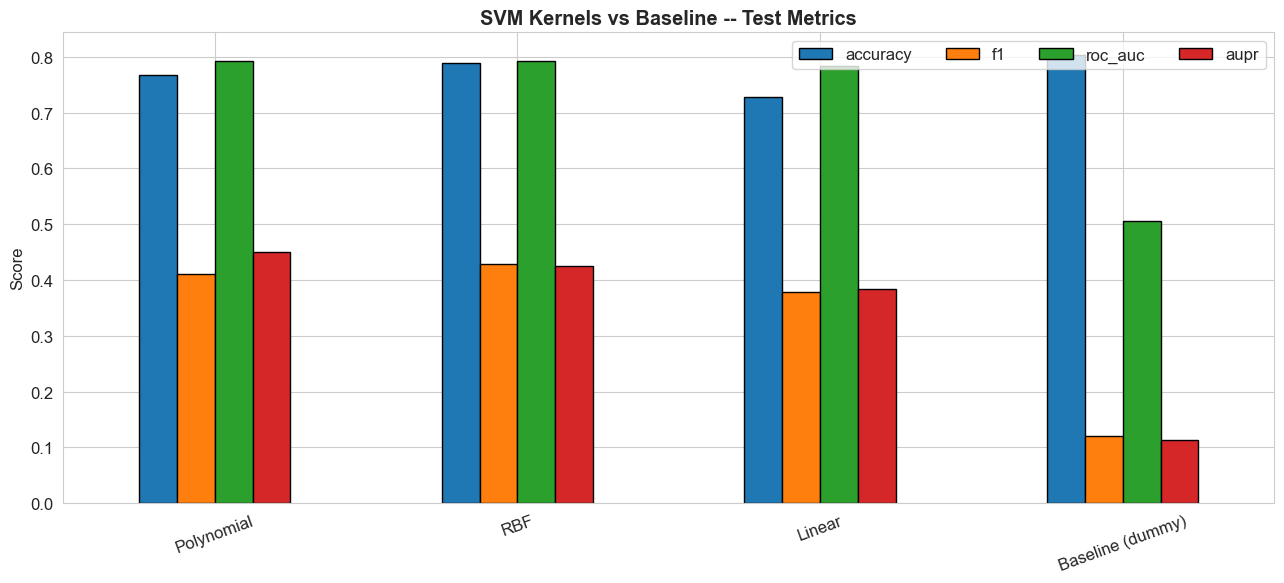

In [9]:
# Visual comparison of the tuned kernels + baseline across metrics
plot_df = compare[['accuracy', 'f1', 'roc_auc', 'aupr']]
ax = plot_df.plot(kind='bar', figsize=(13, 6), edgecolor='black')
ax.set_title('SVM Kernels vs Baseline -- Test Metrics', fontweight='bold')
ax.set_ylabel('Score'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper right', ncol=4)
plt.tight_layout()
plt.show()

---
## 6. Linear-SVM Coefficients — Feature View

The RBF/poly kernels are not directly interpretable (no per-feature weights), but the **linear**
SVM is — like logistic regression, its `coef_` gives a per-feature contribution. We inspect it to
check the drivers agree with Phase I / II.

In [ ]:
lin_svm = tuned['Linear']
svm_coef = pd.Series(lin_svm.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)

print("Linear-SVM coefficients (top 15 by |weight|):")
print(svm_coef.head(15).round(3).to_string())

top = svm_coef.head(15).sort_values()
plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top.values]
plt.barh(range(len(top)), top.values, color=colors, edgecolor='black')
plt.yticks(range(len(top)), top.index)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.xlabel('Linear-SVM coefficient')
plt.title('Top 15 Linear-SVM Coefficients', fontweight='bold')
plt.tight_layout()
plt.show()

# The tuned linear SVM (C=0.01, i.e. STRONG regularization) gives small, stable weights dominated
# by calendar months (nov/may/sep/jun negative, mar positive) and the macro block
# (emp.var.rate -0.51, nr.employed -0.27, euribor3m -0.18). Crucially, here the macro features are
# ALL negative and aligned -- unlike the Phase II logistic at C=1 where euribor3m/nr.employed
# flipped positive. This is the same lesson as Phase II's strong-λ regime: heavy regularization
# pulls the collinear macro block together into a consistent sign, taming the multicollinearity
# instability. The dominant drivers (economy + campaign timing, job_retired) match EDA / Phase I,
# so even the non-linear winner is leaning on the same signal -- just shaped slightly differently.

---
## 7. Summary & Discussion

### Key Findings — Phase III

**Setup:**
- Same features and split as Phase II. Kernel SVMs are O(n²)–O(n³), so we tuned on a stratified
  **8,000-row subsample** (3-fold CV, grid search on **ROC-AUC**, `class_weight='balanced'`) and
  evaluated every final model on the **full 8,238-row test set** for comparability.

**Kernel comparison:**
- All three kernels beat the baseline massively (ROC-AUC 0.505 → ~0.79) and land in a **tight band**
  (test ROC-AUC 0.784–0.793, AUPR 0.38–0.45).
- **Polynomial (degree 2)** is marginally best (ROC-AUC 0.793, AUPR 0.451); **RBF** is essentially
  tied (0.792 / 0.424); **Linear** trails slightly (0.784 / 0.384).
- Tuning favoured **smooth / strongly-regularized** settings (Linear `C=0.01`, Poly `degree=2`,
  RBF wide `gamma=0.01`) — the data does not reward sharp non-linear boundaries.

**Interpretation:**
- The kernels essentially **match the Phase II logistic model** (ROC-AUC ~0.797, AUPR ~0.428);
  Polynomial's AUPR slightly exceeds it — while training on only 8k rows vs logistic's 33k.
- Near-identical performance across linear and non-linear kernels means the decision boundary is
  **approximately linear** in this feature space; the extra capacity of RBF/poly yields little.
- Every linear-ish model in the project plateaus at the same **~0.79 ROC-AUC / ~0.45 AUPR ceiling**,
  reflecting the heavy class overlap diagnosed in Phase I.
- Tuning on ROC-AUC raised the ranking metrics but lowered F1/accuracy vs the defaults
  (precision↓ / recall↑) — a reminder to align the tuning metric with the deployment objective.

**Dataset challenges:**
- **Scalability:** kernel-SVM cost forced subsampling for tuning — a real limitation at 41k rows.
  Scalable alternatives: `LinearSVC`, Nystroem kernel approximation + linear model, or SGD.
- **Class imbalance + class overlap** cap the achievable precision (low precision at high recall).

**Implications for later phases:**
- Since non-linear kernels do **not** beat the linear models here, the main remaining hope for a
  real jump is **ensemble methods** that capture feature interactions differently (Phase IV:
  Random Forest, boosting) — and which also handle the mixed/collinear features more naturally.

---

*Phase IV will focus on Ensemble Methods (Random Forest, AdaBoost / Gradient Boosting).*